In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install --upgrade --force-reinstall sympy



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 34.7 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompa

In [3]:
from huggingface_hub import login
login()

In [4]:
# STEP 0: Imports
import pandas as pd
import torch
import torch.nn as nn
from transformers import LongformerModel, LongformerPreTrainedModel, AutoTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# STEP 1: Define the custom model class
class MultiTraitLongformer(LongformerPreTrainedModel):
    def __init__(self, config, weights_tensor=None):
        super().__init__(config)
        self.longformer = LongformerModel(config)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(config.hidden_size, 15)
        self.weights_tensor = weights_tensor
        self.init_weights()

    def forward(self, input_ids, attention_mask=None, labels_big5=None):
        outputs = self.longformer(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = self.dropout(outputs.last_hidden_state[:, 0])
        logits = self.classifier(cls_output).view(-1, 5, 3)

        loss = None
        if labels_big5 is not None:
            loss = 0
            for i in range(5):
                weight = self.weights_tensor[i].to(logits.device) if self.weights_tensor is not None else None
                loss_fct = nn.CrossEntropyLoss(weight=weight)
                loss += loss_fct(logits[:, i, :], labels_big5[:, i])
            loss /= 5

        return {"loss": loss, "logits": logits}


In [5]:
# STEP 2: Load evaluation data
EVAL_PATH = "/content/drive/MyDrive/NLP-Sentiment-Analysis/val_data.csv"
df = pd.read_csv(EVAL_PATH)
df["text"] = df[["Q1", "Q2", "Q3"]].astype(str).agg(" ".join, axis=1)

# STEP 3: Trait definitions
TRAITS = [
    ("openness", "Openness"),
    ("conscientiousness", "Conscientiousness"),
    ("extraversion", "Extraversion"),
    ("agreeableness", "Agreeableness"),
    ("neuroticism", "Emotional stability")
]
label_from_index = lambda idx: ["low", "medium", "high"][idx]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/835 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]


🔍 Evaluating trait predictions...
 - Openness         : 46.88%
 - Conscientiousness: 31.25%
 - Extraversion     : 46.88%
 - Agreeableness    : 18.75%
 - Neuroticism      : 40.62%


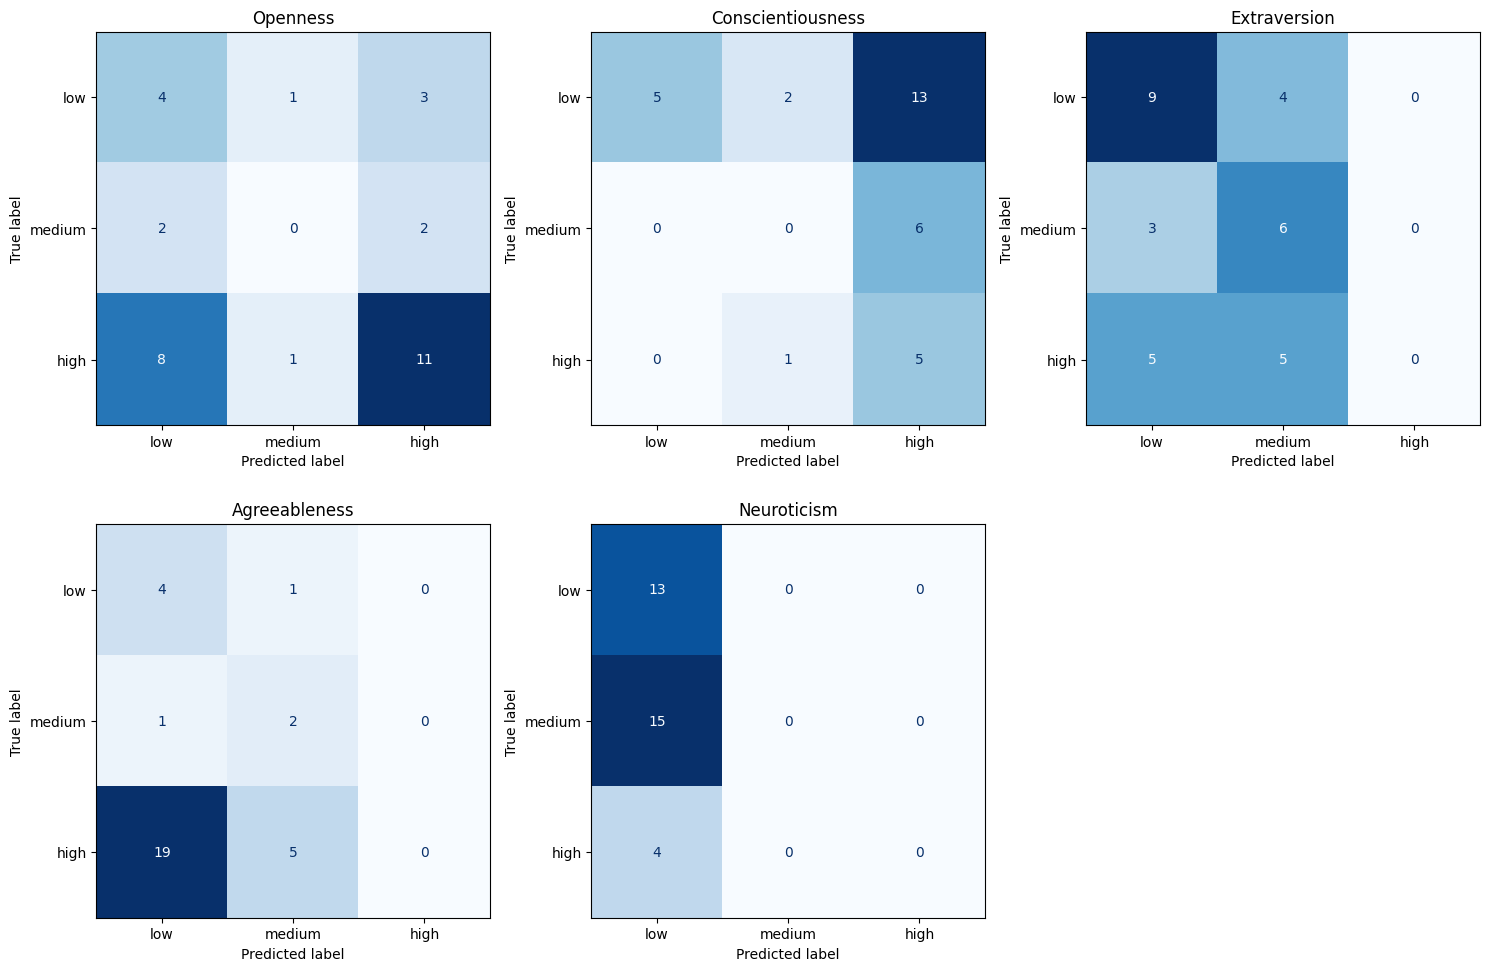


✅ Predictions saved to /content/drive/MyDrive/NLP-Sentiment-Analysis/output_with_predictions_hf.csv


In [6]:
# STEP 4: Load model from Hugging Face (using trust_remote_code=False since it's custom)
MODEL_REPO = "Zvoni/longformer-big5-mbti"  # ⚠️ Ensure this model matches your class!
model = MultiTraitLongformer.from_pretrained(MODEL_REPO, use_safetensors=True)
tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)
model.eval()

# STEP 5: Tokenize data
inputs = tokenizer(df["text"].tolist(), padding=True, truncation=True, max_length=512, return_tensors="pt")

# STEP 6: Predict
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs["logits"]
    predictions = torch.argmax(logits, dim=2).tolist()

# STEP 7: Store predictions and calculate accuracy
print("\n🔍 Evaluating trait predictions...")
for i, (trait_key, trait_col) in enumerate(TRAITS):
    df[f"{trait_key}_pred_label"] = [label_from_index(p[i]) for p in predictions]
    df[f"{trait_key}_match"] = df[trait_col].str.lower() == df[f"{trait_key}_pred_label"]
    acc = df[f"{trait_key}_match"].mean()
    print(f" - {trait_key.title():<17}: {acc:.2%}")

# STEP 8: Plot confusion matrices
labels = ["low", "medium", "high"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (trait_key, trait_col) in enumerate(TRAITS):
    y_true = df[trait_col].str.lower()
    y_pred = df[f"{trait_key}_pred_label"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(trait_key.title())

axes[-1].axis("off")
plt.tight_layout()
plt.show()

# STEP 9: Save predictions
OUTPUT_PATH = "/content/drive/MyDrive/NLP-Sentiment-Analysis/output_with_predictions_hf.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"\n✅ Predictions saved to {OUTPUT_PATH}")


In [7]:
from sklearn.metrics import f1_score

# Initialize metrics storage
results = []

# Compute accuracy and macro F1 per trait
for i, (trait_key, trait_col) in enumerate(TRAITS):
    y_true = df[trait_col].str.lower()
    y_pred = df[f"{trait_key}_pred_label"]
    acc = (y_true == y_pred).mean()
    f1 = f1_score(y_true, y_pred, average="macro", labels=["low", "medium", "high"])

    results.append({
        "Trait": trait_key.title(),
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4)
    })

# Add macro average across all traits
macro_acc = sum([r["Accuracy"] for r in results]) / len(results)
macro_f1 = sum([r["F1 Score"] for r in results]) / len(results)
results.append({
    "Trait": "Macro Avg",
    "Accuracy": round(macro_acc, 4),
    "F1 Score": round(macro_f1, 4)
})

# Create and display DataFrame
metrics_df = pd.DataFrame(results)
print("\n📊 Trait-level performance:")
display(metrics_df)



📊 Trait-level performance:


,Trait,Accuracy,F1 Score
0,Openness,0.4688,0.3249
1,Conscientiousness,0.3125,0.2444
2,Extraversion,0.4688,0.3667
3,Agreeableness,0.1875,0.2132
4,Neuroticism,0.4062,0.1926
5,Macro Avg,0.3688,0.2684
